<a href="https://colab.research.google.com/github/ArifahZhafirah/PEMBELAJARAN-MESIN/blob/main/JS06/TUGASLAB/PEMMESTUGAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Lab JS06 - Klasifikasi 2 (SVM)

**Soal 1.** Buatlah model SVM dengan menggunakan data `voice.csv` dengan ketentuan:
1. Split data dengan rasio 70:30 dan 80:20 untuk setiap model yang akan dibangun.
   1. Gunakan model dengan kernel linier.
   2. Gunakan model dengan kernel polynomial.
   3. Gunakan model dengan kernel RBF.
2. Tabulasikan performansi setiap split dan kernel berdasarkan metrik akurasi.

**Soal 2.** Gunakan data pada praktikum 5 untuk membuat model klasifikasi siang dan malam menggunakan SVM dengan kernel RBF menggunakan fitur histogram. Gunakan rasio 80:20. Anda dapat bereksperimen dengan hyperparameter tuning dari kernel RBF. Catat performansi akurasinya!

---
# SOAL 1 - SVM pada `voice.csv`

## Persiapan - Import Library dan Load Data

In [12]:
# import library yang dibutuhin
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [13]:
# baca file voice.csv, cek ukuran datanya dulu
data = pd.read_csv('voice.csv')
print(data.shape)
data.head()

(3168, 21)


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [14]:
# lihat jumlah tiap label sama ada missing value atau tidak
print(data['label'].value_counts())
print(data.isnull().sum().sum())

label
male      1584
female    1584
Name: count, dtype: int64
0


In [15]:
# pisah fitur (X) dan label (y)
X = data.drop('label', axis=1)
y = data['label']

Dari hasil cek di atas, data sudah siap dipakai. Modelnya dibuat pakai `make_pipeline` seperti di Lab 4, tapi tahap awalnya `StandardScaler` (bukan PCA), karena skala antar fitur di `voice.csv` beda jauh jadi perlu distandarisasi dulu.

## 1.1 Split Data 70:30 dan 80:20

In [16]:
# split 70:30 -> training 70%, testing 30%
Xtrain70, Xtest70, ytrain70, ytest70 = train_test_split(X, y, test_size=0.3, random_state=42)

# split 80:20 -> training 80%, testing 20%
Xtrain80, Xtest80, ytrain80, ytest80 = train_test_split(X, y, test_size=0.2, random_state=42)

# cek jumlah datanya
print('Split 70:30 :', Xtrain70.shape, Xtest70.shape)
print('Split 80:20 :', Xtrain80.shape, Xtest80.shape)

Split 70:30 : (2217, 20) (951, 20)
Split 80:20 : (2534, 20) (634, 20)


### 1.1.1 Model dengan Kernel Linier

In [17]:
svc = SVC(kernel='linear')
model = make_pipeline(StandardScaler(), svc)

# latih & uji pakai split 70:30
model.fit(Xtrain70, ytrain70)
yfit = model.predict(Xtest70)
acc_linear_70 = accuracy_score(ytest70, yfit)

# latih & uji pakai split 80:20
model.fit(Xtrain80, ytrain80)
yfit = model.predict(Xtest80)
acc_linear_80 = accuracy_score(ytest80, yfit)

print(f'Akurasi linier 70:30: {acc_linear_70:.4f}')
print(f'Akurasi linier 80:20: {acc_linear_80:.4f}')

Akurasi linier 70:30: 0.9706
Akurasi linier 80:20: 0.9763


### 1.1.2 Model dengan Kernel Polynomial

In [18]:
svc = SVC(kernel='poly')
model = make_pipeline(StandardScaler(), svc)

# latih & uji pakai split 70:30
model.fit(Xtrain70, ytrain70)
yfit = model.predict(Xtest70)
acc_poly_70 = accuracy_score(ytest70, yfit)

# latih & uji pakai split 80:20
model.fit(Xtrain80, ytrain80)
yfit = model.predict(Xtest80)
acc_poly_80 = accuracy_score(ytest80, yfit)

print(f'Akurasi polynomial 70:30: {acc_poly_70:.4f}')
print(f'Akurasi polynomial 80:20: {acc_poly_80:.4f}')

Akurasi polynomial 70:30: 0.9579
Akurasi polynomial 80:20: 0.9716


### 1.1.3 Model dengan Kernel RBF

In [19]:
svc = SVC(kernel='rbf')
model = make_pipeline(StandardScaler(), svc)

# latih & uji pakai split 70:30
model.fit(Xtrain70, ytrain70)
yfit = model.predict(Xtest70)
acc_rbf_70 = accuracy_score(ytest70, yfit)

# latih & uji pakai split 80:20
model.fit(Xtrain80, ytrain80)
yfit = model.predict(Xtest80)
acc_rbf_80 = accuracy_score(ytest80, yfit)

print(f'Akurasi RBF 70:30: {acc_rbf_70:.4f}')
print(f'Akurasi RBF 80:20: {acc_rbf_80:.4f}')

Akurasi RBF 70:30: 0.9811
Akurasi RBF 80:20: 0.9826


## 1.2 Tabulasi Performansi (Akurasi) Setiap Split dan Kernel

**Tabel 1.** Akurasi model SVM pada `voice.csv` berdasarkan kernel dan rasio split

In [20]:
# gabungin semua akurasi ke satu tabel biar gampang dibandingin
hasil = pd.DataFrame({'Kernel': ['Linier', 'Polynomial', 'RBF'],
                      'Akurasi 70:30': [acc_linear_70, acc_poly_70, acc_rbf_70],
                      'Akurasi 80:20': [acc_linear_80, acc_poly_80, acc_rbf_80]})
hasil

,Kernel,Akurasi 70:30,Akurasi 80:20
0,Linier,0.970557,0.976341
1,Polynomial,0.957939,0.971609
2,RBF,0.981073,0.982650


**Kesimpulan Soal 1:** Kernel RBF paling bagus di kedua split, yaitu 0,9811 untuk 70:30 dan 0,9826 untuk 80:20. Di bawahnya ada kernel linier (0,9706 dan 0,9763), lalu polynomial yang paling rendah (0,9579 dan 0,9716). Jadi urutannya RBF, linier, lalu polynomial.

Kalau dilihat dari rasio split, akurasi 80:20 sedikit lebih tinggi daripada 70:30 untuk ketiga kernel. Kenaikan paling kelihatan ada di polynomial (sekitar 1,4 poin), sedangkan RBF hampir sama (sekitar 0,15 poin). Mungkin karena polynomial lebih butuh data latih yang banyak, tapi ini hanya dugaan dari hasil yang ada. Selisih antar kernel juga tidak jauh, dan semuanya sudah di atas 95%, jadi data voice.csv memang cukup mudah dipisahkan setelah distandarisasi. Dari percobaan ini, RBF dengan split 80:20 jadi yang terbaik.

---
# SOAL 2 - Klasifikasi Siang dan Malam (SVM RBF, Fitur Histogram, 80:20)

## 2.1 Data Praktikum 5

### 2.1.1 Import Library dan Lokasi Data

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
# import library (sama seperti Lab 5)
from pathlib import Path
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np
import pandas as pd

In [23]:
# lokasi folder gambar
train_dir = "/content/drive/MyDrive/Semester5/Pembelajaran Mesin/TG6_244107020188_Arifah Zhafirah Wikananda/images/training"
test_dir = "/content/drive/MyDrive/Semester5/Pembelajaran Mesin/TG6_244107020188_Arifah Zhafirah Wikananda/images/test"

In [24]:
# pastiin folder gambarnya kebaca (harus True semua)
import os
print(os.getcwd())
print(os.path.exists(train_dir))
print(os.path.exists(test_dir))

/content
True
True


### 2.1.2 Load Data dan Visualisasi

Fungsi `load_dataset` sama seperti di Lab 5. Soal minta rasio 80:20, jadi data training dan data test digabung dulu, nanti dibagi ulang di langkah 2.3.

In [25]:
# fungsi buat baca semua gambar beserta labelnya
def load_dataset(img_dir):
    p = Path(img_dir)
    dirs = p.glob('*')

    img_list = []

    for dir in dirs:
        label = str(dir).split('/')[-1]
        for file in dir.glob('*.jpg'):
            img = mpimg.imread(file)

            if not img is None:
                img_list.append((img, label))

    return img_list

In [26]:
# load data training dan test, terus digabung
train_img = load_dataset(train_dir)
test_img = load_dataset(test_dir)
all_img = train_img + test_img
print(f'Jumlah gambar: {len(all_img)}')

Jumlah gambar: 400


In [27]:
# cek data pertama, harusnya tuple (gambar, label)
all_img[0]

(array([[[ 66,  96, 124],
         [ 66,  96, 124],
         [ 66,  96, 124],
         ...,
         [ 58,  80, 101],
         [ 58,  80, 101],
         [ 58,  80, 101]],
 
        [[ 66,  96, 124],
         [ 66,  96, 124],
         [ 66,  96, 124],
         ...,
         [ 58,  80, 101],
         [ 58,  80, 101],
         [ 58,  80, 101]],
 
        [[ 66,  96, 124],
         [ 66,  96, 124],
         [ 66,  96, 124],
         ...,
         [ 58,  80, 101],
         [ 58,  80, 101],
         [ 58,  80, 101]],
 
        ...,
 
        [[104,  66,  55],
         [102,  64,  53],
         [ 99,  61,  50],
         ...,
         [ 91,  91,  83],
         [ 90,  90,  82],
         [ 77,  77,  69]],
 
        [[ 95,  55,  45],
         [ 96,  56,  46],
         [ 96,  56,  46],
         ...,
         [ 96,  96,  88],
         [ 96,  96,  88],
         [ 84,  84,  76]],
 
        [[ 94,  51,  42],
         [100,  60,  50],
         [108,  68,  58],
         ...,
         [ 97,  97,  89],
  

In [28]:
# cek ukuran salah satu gambar secara acak
pick_random = np.random.randint(0, len(all_img))

print(f'Image {pick_random}')
print(all_img[pick_random][0].shape)

Image 312
(439, 640, 3)


In [29]:
# fungsi buat nampilin gambar acak
def random_img_viz(img_list):
    rand_num = np.random.randint(0, len(img_list))

    img = img_list[rand_num][0]
    label = img_list[rand_num][1]
    label_str = 'day' if label == 1 else 'night'

    plt.imshow(img)
    print(f'Shape\t: {img.shape}')
    print(f'Label\t: {label}')

Shape	: (700, 1280, 3)
Label	: day


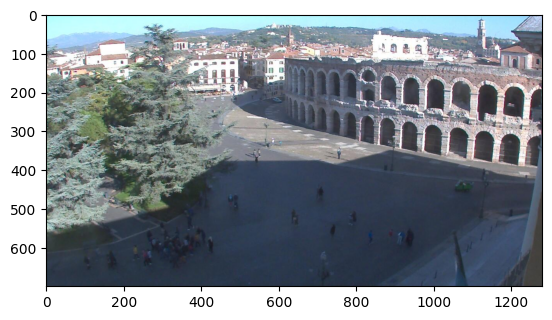

In [30]:
random_img_viz(all_img)

### 2.1.3 Pra Pengolahan Data

In [31]:
# samain ukuran semua gambar
def standarized_input(image):
    # resize ke lebar 1100, tinggi 600
    std_img = cv2.resize(image, (1100,600))

    return std_img

In [32]:
# ubah label jadi angka: day = 1, night = 0
def label_encoder(label):
    num_val = 0

    if(label == 'day'):
        num_val = 1

    return num_val

In [33]:
# jalanin resize + encoding label ke semua gambar
def preprocess(img_list):
    std_img_list = []

    for item in img_list:
        image = item[0]
        label = item[1]

        # samain ukuran gambar
        std_img = standarized_input(image)

        # encoding label
        img_label = label_encoder(label)

        std_img_list.append((std_img, img_label))

    return std_img_list

In [34]:
std_img_list = preprocess(all_img)

# cek ukuran lagi setelah di-resize
pick_random = np.random.randint(0, len(std_img_list))

print(f'Image {pick_random}')
print(std_img_list[pick_random][0].shape)

Image 312
(600, 1100, 3)


Shape	: (600, 1100, 3)
Label	: 0


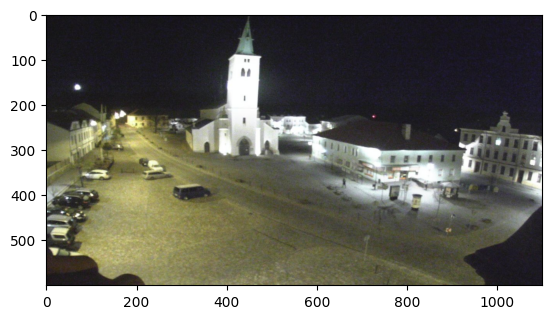

In [35]:
# lihat gambar hasil pra pengolahan
random_img_viz(std_img_list)

## 2.2 Ekstraksi Fitur Histogram

Strukturnya mengikuti fungsi `avg_brightness` dan `extract_avg_bright_feature` di Lab 5 (RGB diubah ke HSV dulu). Bedanya, yang diambil bukan rata-rata kecerahan, tapi histogram kanal V (32 bin) yang sudah dinormalisasi.

In [36]:
# fitur histogram dari kanal V (kecerahan) di HSV
def histogram_feature(image, bins=32):
    # ubah ke HSV
    img_hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # hitung histogram kanal V (channel ke-3)
    hist = cv2.calcHist([img_hsv], [2], None, [bins], [0, 256])

    # normalisasi biar total semua bin = 1
    hist = hist.flatten() / hist.sum()

    return hist

Image 217
Shape histogram: (32,)


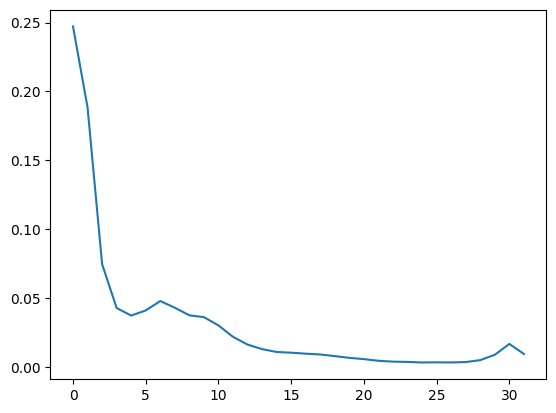

In [37]:
# coba di satu gambar acak (pakai gambar yang sudah di-resize)
rand_img = np.random.randint(0, len(std_img_list))

feature_img = std_img_list[rand_img][0]

hist_img = histogram_feature(feature_img)

print(f'Image {rand_img}')
print(f'Shape histogram: {hist_img.shape}')
plt.plot(hist_img)

In [38]:
# ekstrak fitur dari semua gambar, simpan di dataframe
def extract_histogram_feature(img_list):
    hist_list = []
    labels = []

    for img in img_list:
        img_hist = histogram_feature(img[0]) # histogram dari gambar
        img_label = img[1] # label gambar

        hist_list.append(img_hist)
        labels.append(img_label)

    # gabungin fitur dan label per kolom
    data = np.column_stack((hist_list, labels))
    # bikin dataframe
    columns = [f'BIN_{i}' for i in range(len(hist_list[0]))] + ['LABELS']
    df = pd.DataFrame(data, columns=columns)

    return df

In [39]:
hist_df = extract_histogram_feature(std_img_list)
print(f'Shape: {hist_df.shape}')
hist_df.head()

Shape: (400, 33)


,BIN_0,BIN_1,BIN_2,BIN_3,BIN_4,BIN_5,BIN_6,BIN_7,BIN_8,BIN_9,...,BIN_23,BIN_24,BIN_25,BIN_26,BIN_27,BIN_28,BIN_29,BIN_30,BIN_31,LABELS
0,0.002102,0.015118,0.021389,0.030844,0.038114,0.038939,0.030461,0.025250,0.022935,0.018868,...,0.015767,0.011435,0.007421,0.005662,0.004432,0.003905,0.003665,0.004183,0.008023,1.0
1,0.000479,0.007764,0.022180,0.031714,0.044594,0.068242,0.117438,0.123585,0.077818,0.056902,...,0.032376,0.035171,0.032894,0.035262,0.030965,0.022832,0.017327,0.006035,0.000032,1.0
2,0.000000,0.000002,0.000129,0.005353,0.012170,0.018876,0.015926,0.016705,0.024105,0.032052,...,0.022330,0.018220,0.013758,0.013447,0.013670,0.010918,0.006171,0.004879,0.147018,1.0
3,0.000000,0.000000,0.000002,0.000076,0.001058,0.010953,0.035145,0.038994,0.044397,0.045752,...,0.013153,0.012705,0.013586,0.013479,0.011317,0.009323,0.008205,0.009302,0.111023,1.0
4,0.002941,0.029241,0.043235,0.045894,0.039432,0.031205,0.025498,0.023523,0.026718,0.025802,...,0.006227,0.005421,0.004720,0.004018,0.003714,0.003303,0.003276,0.004089,0.009952,1.0


## 2.3 Split Data 80:20

In [40]:
# pisah fitur dan label, lalu split 80:20
from sklearn.model_selection import train_test_split

X = hist_df.iloc[:,:-1].values
y = hist_df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(320, 32) (80, 32)


## 2.4 Model SVM Kernel RBF

In [41]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# prediksi data train dan data test
y_train_pred = model.predict(X_train)
acc_train_default = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
acc_test_default = accuracy_score(y_test, y_test_pred)

print(f'Accuracy on train: {acc_train_default}')
print(f'Accuracy on test: {acc_test_default}')

Accuracy on train: 0.990625
Accuracy on test: 1.0


## 2.5 Hyperparameter Tuning Kernel RBF (GridSearchCV, seperti Lab 4)

In [42]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

svc = SVC(kernel='rbf')
model = make_pipeline(StandardScaler(), svc)

# coba beberapa kombinasi C dan gamma
param_grid = {'svc__C': [1, 5, 10, 50, 100],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

CPU times: user 1.04 s, sys: 0 ns, total: 1.04 s
Wall time: 1.05 s
{'svc__C': 5, 'svc__gamma': 0.05}
0.990625


In [43]:
# pakai model terbaik hasil grid search
model = grid.best_estimator_
yfit = model.predict(X_test)

acc_train_tuning = accuracy_score(y_train, model.predict(X_train))
acc_test_tuning = accuracy_score(y_test, yfit)

print(f'Accuracy on train: {acc_train_tuning}')
print(f'Accuracy on test: {acc_test_tuning}')

Accuracy on train: 1.0
Accuracy on test: 1.0


### 2.5.1 Cek Performansi Model Terbaik

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, yfit, target_names=['night', 'day']))

              precision    recall  f1-score   support

       night       1.00      1.00      1.00        38
         day       1.00      1.00      1.00        42

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



Text(113.9222222222222, 0.5, 'predicted label')

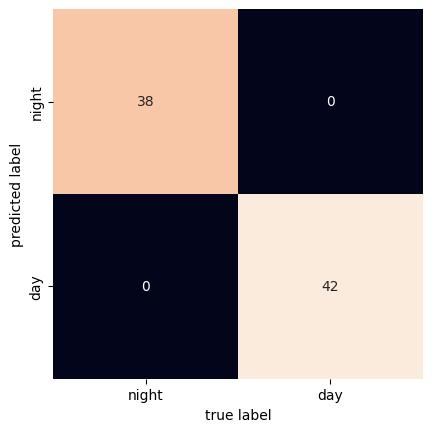

In [45]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

mat = confusion_matrix(y_test, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=['night', 'day'],
            yticklabels=['night', 'day'])
plt.xlabel('true label')
plt.ylabel('predicted label')

## 2.6 Catat Performansi Akurasi

**Tabel 2.** Akurasi model SVM kernel RBF (fitur histogram, split 80:20) pada klasifikasi siang dan malam

In [46]:
# bandingin model default dengan model hasil tuning
hasil_siang_malam = pd.DataFrame({'Model': ['RBF default', 'RBF tuning (GridSearchCV)'],
                                  'Akurasi train': [acc_train_default, acc_train_tuning],
                                  'Akurasi test': [acc_test_default, acc_test_tuning]})
hasil_siang_malam

,Model,Akurasi train,Akurasi test
0,RBF default,0.990625,1.0
1,RBF tuning (GridSearchCV),1.000000,1.0


**Kesimpulan Soal 2:** Klasifikasi siang dan malam pakai SVM kernel RBF dengan fitur histogram kanal V hasilnya sangat bagus. Model default sudah dapat akurasi test 1,0 (train 0,9906). Setelah tuning dengan GridSearchCV, parameter terbaiknya C = 5 dan gamma = 0,05, dan akurasi train naik jadi 1,0 dengan akurasi test tetap 1,0.

Jadi tuning tidak menambah akurasi test karena dari awal sudah 100%, yang naik cuma akurasi train. Confusion matrix juga menunjukkan semua 80 data uji (38 malam dan 42 siang) terprediksi benar, sehingga precision, recall, dan f1-score-nya 1,00. Ini menandakan histogram kecerahan memang fitur yang sangat membedakan citra siang dan malam.

Perlu dicatat bahwa data ujinya cuma 80 gambar, jadi hasil 100% belum tentu sama kalau dicoba di data yang lebih banyak. Model default juga dilatih tanpa StandardScaler, sedangkan model tuning pakai pipeline dengan StandardScaler, jadi perbandingannya belum sepenuhnya setara.